# # Notebook 02 — Baseline Models
# **LCGA Self-Healing IDS | Addis Ababa University**
# 
# Trains three baselines on CICIDS2017:
# 1. Random Forest
# 2. Standalone Conv1D
# 3. Standalone GRU
# 
# Also trains binary ANN+GRU ensemble on NSL-KDD for detection.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, os, joblib, json, warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, matthews_corrcoef,
                             classification_report, confusion_matrix)

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

# ── Paths ──
IN_DIR    = "/kaggle/input/notebooks/getayefiseha/notebook-01-preprocessing-for-model-training/processed"
MODEL_DIR = "/kaggle/working/models"
RES_DIR   = "/kaggle/working/results"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)

# ── Metric helper ──
def get_metrics(y_true, y_pred, model_name, params="—", infer_ms=0.0, train_s=0.0):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Params": params,
        "Train (s)": f"{train_s:.1f}",
        "Infer (ms)": f"{infer_ms:.2f}",
    }

results_cic = []
print("Setup complete ✓")

2026-05-19 10:23:41.062783: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779186221.263624      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779186221.323991      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779186221.799785      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779186221.799899      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779186221.799902      16 computation_placer.cc:177] computation placer alr

TF: 2.19.0
GPU: []
Setup complete ✓


2026-05-19 10:24:10.246444: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# ## A. CICIDS2017 Baselines

In [2]:
# ==================== A.1 Load CICIDS2017 ====================
# Flat versions for Random Forest
X_tr_flat = np.load(os.path.join(IN_DIR, "cic_Xtrain_flat.npy"))
y_tr_cic  = np.load(os.path.join(IN_DIR, "cic_ytrain.npy"))
X_val_flat = np.load(os.path.join(IN_DIR, "cic_Xval_flat.npy"))
y_val_cic  = np.load(os.path.join(IN_DIR, "cic_yval.npy"))
X_te_flat  = np.load(os.path.join(IN_DIR, "cic_Xtest_flat.npy"))
y_te_cic   = np.load(os.path.join(IN_DIR, "cic_ytest.npy"))

# 3D versions for Conv1D/GRU
X_tr_3d = np.load(os.path.join(IN_DIR, "cic_Xtrain_3d.npy"))
X_val_3d = np.load(os.path.join(IN_DIR, "cic_Xval_3d.npy"))
X_te_3d  = np.load(os.path.join(IN_DIR, "cic_Xtest_3d.npy"))

# Class names and counts
class_names = joblib.load(os.path.join(IN_DIR, "cic_classes.pkl"))
n_features  = X_tr_flat.shape[1]
n_classes   = len(class_names)

print(f"Features: {n_features} | Classes: {n_classes}")
print(f"Train: {X_tr_flat.shape} | Val: {X_val_flat.shape} | Test: {X_te_flat.shape}")
print(f"Train 3D: {X_tr_3d.shape}")

Features: 73 | Classes: 12
Train: (1533137, 73) | Val: (503731, 73) | Test: (503731, 73)
Train 3D: (1533137, 73, 1)


In [3]:
# ### A.2 Random Forest Baseline

print("Training Random Forest …")
t0 = time.perf_counter()
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_tr_flat, y_tr_cic)
train_time = time.perf_counter() - t0

y_pred_rf = rf.predict(X_te_flat)

# Latency
t0 = time.perf_counter()
for _ in range(100):
    rf.predict(X_te_flat[:1])
rf_lat = (time.perf_counter()-t0)/100*1000

results_cic.append(get_metrics(y_te_cic, y_pred_rf, "Random Forest",
                                params="100 trees", infer_ms=rf_lat, train_s=train_time))
print(f"RF Macro F1: {results_cic[-1]['Macro F1']:.4f} | Time: {train_time:.1f}s")

joblib.dump(rf, os.path.join(MODEL_DIR, "rf_baseline.pkl"))
print("RF saved ✓")

Training Random Forest …
RF Macro F1: 0.9527 | Time: 349.2s
RF saved ✓


In [4]:
# ### A.3 Standalone Conv1D Baseline

print("Building Conv1D baseline …")

cnn = models.Sequential([
    layers.Conv1D(64, 3, padding="same", activation="relu", input_shape=(n_features, 1)),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation="relu"),
    layers.Dense(n_classes, activation="softmax")
], name="CNN_baseline")
cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn.summary()

t0 = time.perf_counter()
hist_cnn = cnn.fit(X_tr_3d, y_tr_cic, validation_data=(X_val_3d, y_val_cic),
                   epochs=30, batch_size=256, verbose=1,
                   callbacks=[callbacks.EarlyStopping(patience=5, restore_best_weights=True)])
train_cnn = time.perf_counter() - t0

y_pred_cnn = np.argmax(cnn.predict(X_te_3d, verbose=0), axis=1)

times = []
for _ in range(300):
    t0 = time.perf_counter()
    cnn(X_te_3d[:1], training=False)
    times.append((time.perf_counter() - t0) * 1000)
cnn_lat = np.mean(times[50:])

results_cic.append(get_metrics(y_te_cic, y_pred_cnn, "CNN baseline",
                                params=f"{cnn.count_params():,}", infer_ms=cnn_lat, train_s=train_cnn))
print(f"CNN Macro F1: {results_cic[-1]['Macro F1']:.4f} | Latency: {cnn_lat:.2f}ms")

cnn.save(os.path.join(MODEL_DIR, "cnn_baseline.keras"))
print("CNN saved ✓")

Building Conv1D baseline …


Model: "CNN_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 73, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,196 (20.30 KB)

 Trainable params: 5,196 (20.30 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
5989/5989 ━━━━━━━━━━━━━━━━━━━━ 55s 9ms/step - accuracy: 0.8257 - loss: 0.7528 - val_accuracy: 0.8911 - val_loss: 0.4578
Epoch 2/30
5989/5989 ━━━━━━━━━━━━━━━━━━━━ 53s 9ms/step - accuracy: 0.8764 - loss: 0.4295 - val_accuracy: 0.9103 - val_loss: 0.3153
Epoch 3/30
5989/5989 ━━━━━━━━━━━━━━━━━━━━ 52s 9ms/step - accuracy: 0.9052 - loss: 0.3601 - val_accuracy: 0.9254 - val_loss: 0.2592
Epoch 4/30
5989/5989 ━━━━━━━━━━━━━━━━━━━━ 52s 9ms/step - accuracy: 0.9182 - loss: 0.3121 - val_accuracy: 0.9341 - val_loss: 0.2413
Epoch 5/30
5989/5989 ━━━━━━━━━━━━━━━━━━━━ 53s 9ms/step - accuracy: 0.9260 - loss: 0.2811 - val_accuracy: 0.9341 - val_loss: 0.2138
Epoch 6/30
5989/5989 ━━━━━━━━━━━━━━━━━━━━ 53s 9ms/step - accuracy: 0.9295 - loss: 0.2582 - val_accuracy: 0.9350 - val_loss: 0.2057
Epoch 7/30
5989/5989 ━━━━━━━━━━━━━━━━━━━━ 54s 9ms/step - accuracy: 0.9279 - loss: 0.3965 - val_accuracy: 0.9413 - val_loss: 0.2405
Epoch 8/30
5989/5989 ━━━━━━━━━━━━━━━━━━━━ 53s 9ms/step - accuracy: 0.9313 - loss: 0

In [5]:
# ### A.4 Standalone GRU Baseline
print("Building GRU baseline …")

gru = models.Sequential([
    layers.GRU(64, input_shape=(n_features, 1)),
    layers.Dense(64, activation="relu"),
    layers.Dense(n_classes, activation="softmax")
], name="GRU_baseline")
gru.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
gru.summary()

t0 = time.perf_counter()
hist_gru = gru.fit(X_tr_3d, y_tr_cic, validation_data=(X_val_3d, y_val_cic),
                   epochs=30, batch_size=256, verbose=1,
                   callbacks=[callbacks.EarlyStopping(patience=5, restore_best_weights=True)])
train_gru = time.perf_counter() - t0

y_pred_gru = np.argmax(gru.predict(X_te_3d, verbose=0), axis=1)

times = []
for _ in range(300):
    t0 = time.perf_counter()
    gru(X_te_3d[:1], training=False)
    times.append((time.perf_counter() - t0) * 1000)
gru_lat = np.mean(times[50:])

results_cic.append(get_metrics(y_te_cic, y_pred_gru, "GRU baseline",
                                params=f"{gru.count_params():,}", infer_ms=gru_lat, train_s=train_gru))
print(f"GRU Macro F1: {results_cic[-1]['Macro F1']:.4f} | Latency: {gru_lat:.2f}ms")

gru.save(os.path.join(MODEL_DIR, "gru_baseline.keras"))
print("GRU saved ✓")

Building GRU baseline …


Model: "GRU_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,804 (69.55 KB)

 Trainable params: 17,804 (69.55 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
5989/5989 ━━━━━━━━━━━━━━━━━━━━ 730s 122ms/step - accuracy: 0.9329 - loss: 0.2846 - val_accuracy: 0.9965 - val_loss: 0.0151
Epoch 2/30
5989/5989 ━━━━━━━━━━━━━━━━━━━━ 738s 123ms/step - accuracy: 0.9947 - loss: 0.0208 - val_accuracy: 0.9970 - val_loss: 0.0122
Epoch 3/30
5989/5989 ━━━━━━━━━━━━━━━━━━━━ 754s 126ms/step - accuracy: 0.9961 - loss: 0.0141 - val_accuracy: 0.9973 - val_loss: 0.0103
Epoch 4/30
5989/5989 ━━━━━━━━━━━━━━━━━━━━ 763s 127ms/step - accuracy: 0.9964 - loss: 0.0130 - val_accuracy: 0.9979 - val_loss: 0.0075
Epoch 5/30
5989/5989 ━━━━━━━━━━━━━━━━━━━━ 757s 126ms/step - accuracy: 0.9967 - loss: 0.0110 - val_accuracy: 0.9980 - val_loss: 0.0072
Epoch 6/30
5989/5989 ━━━━━━━━━━━━━━━━━━━━ 756s 126ms/step - accuracy: 0.9969 - loss: 0.0095 - val_accuracy: 0.9980 - val_loss: 0.0065
Epoch 7/30
5989/5989 ━━━━━━━━━━━━━━━━━━━━ 750s 125ms/step - accuracy: 0.9972 - loss: 0.0086 - val_accuracy: 0.9977 - val_loss: 0.0073
Epoch 8/30
5989/5989 ━━━━━━━━━━━━━━━━━━━━ 751s 125ms/step - ac


===== CICIDS2017 Baseline Comparison =====
        Model  Accuracy  Macro F1  Weighted F1      MCC    Params Train (s) Infer (ms)
Random Forest  0.998448  0.952683     0.998455 0.994815 100 trees     349.2      33.33
 CNN baseline  0.962305  0.639507     0.960005 0.869740     5,196    1642.5       3.76
 GRU baseline  0.998172  0.906989     0.998268 0.993914    17,804   13806.9     230.55


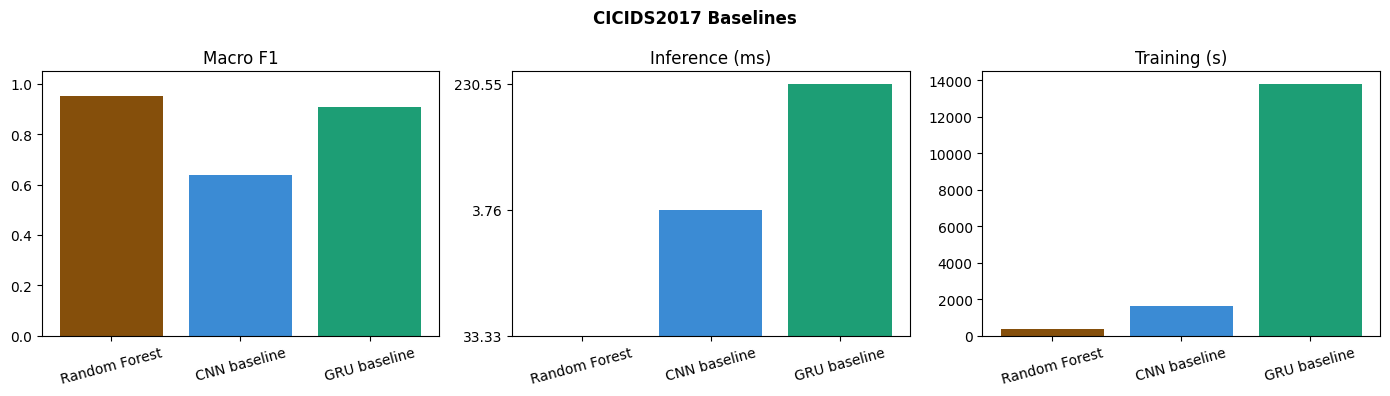

In [6]:
# ==================== A.5 Baseline Comparison ====================
df_baselines = pd.DataFrame(results_cic)
print("\n===== CICIDS2017 Baseline Comparison =====")
print(df_baselines.to_string(index=False))
df_baselines.to_csv(os.path.join(RES_DIR, "baselines_cicids.csv"), index=False)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
names = [r["Model"] for r in results_cic]
macro_f1s = [r["Macro F1"] for r in results_cic]
latencies = [r["Infer (ms)"] for r in results_cic]
train_times = [float(r["Train (s)"]) for r in results_cic]
colors = ["#854F0B","#3B8BD4","#1D9E75"]

axes[0].bar(names, macro_f1s, color=colors); axes[0].set_title("Macro F1"); axes[0].set_ylim(0,1.05)
axes[1].bar(names, latencies, color=colors); axes[1].set_title("Inference (ms)")
axes[2].bar(names, train_times, color=colors); axes[2].set_title("Training (s)")
for ax in axes: ax.tick_params(axis="x", rotation=15)
plt.suptitle("CICIDS2017 Baselines", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, "baselines_comparison.png"), dpi=150)
plt.show()

# ## B. NSL‑KDD Binary Detection Ensemble

In [7]:
# ==================== B.1 Load NSL‑KDD Data ====================
X_tr_flat_nsl = np.load(os.path.join(IN_DIR, "nsl_Xtrain_flat.npy"))
y_tr_nsl      = np.load(os.path.join(IN_DIR, "nsl_ytrain.npy"))
X_tr_seq_nsl  = np.load(os.path.join(IN_DIR, "nsl_Xtrain_seq.npy"))

X_val_flat_nsl = np.load(os.path.join(IN_DIR, "nsl_Xval_flat.npy"))
y_val_nsl      = np.load(os.path.join(IN_DIR, "nsl_yval.npy"))
X_val_seq_nsl  = np.load(os.path.join(IN_DIR, "nsl_Xval_seq.npy"))

X_te_flat_nsl = np.load(os.path.join(IN_DIR, "nsl_Xtest_flat.npy"))
y_te_nsl      = np.load(os.path.join(IN_DIR, "nsl_ytest.npy"))
X_te_seq_nsl  = np.load(os.path.join(IN_DIR, "nsl_Xtest_seq.npy"))

n_feat_nsl = X_tr_flat_nsl.shape[1]
print(f"NSL features: {n_feat_nsl} | Train: {X_tr_flat_nsl.shape} | Val: {X_val_flat_nsl.shape} | Test: {X_te_flat_nsl.shape}")
print(f"Train class dist: {np.bincount(y_tr_nsl)}")

NSL features: 20 | Train: (107752, 20) | Val: (22186, 20) | Test: (22187, 20)
Train class dist: [53876 53876]


In [8]:
# ==================== B.2 ANN Model ====================
ann = models.Sequential([
    layers.Dense(128, activation="relu", input_shape=(n_feat_nsl,)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
], name="ANN_NSL")
ann.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

t0 = time.perf_counter()
ann.fit(X_tr_flat_nsl, y_tr_nsl, validation_data=(X_val_flat_nsl, y_val_nsl),
        epochs=50, batch_size=256, verbose=1,
        callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True)])
t_ann = time.perf_counter() - t0

ann.save(os.path.join(MODEL_DIR, "ann_nsl.keras"))
print(f"ANN trained: {t_ann:.1f}s ✓")

Epoch 1/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9173 - loss: 0.2009 - val_accuracy: 0.9778 - val_loss: 0.0642
Epoch 2/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9717 - loss: 0.0737 - val_accuracy: 0.9814 - val_loss: 0.0514
Epoch 3/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9764 - loss: 0.0624 - val_accuracy: 0.9835 - val_loss: 0.0466
Epoch 4/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9790 - loss: 0.0577 - val_accuracy: 0.9845 - val_loss: 0.0441
Epoch 5/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9795 - loss: 0.0536 - val_accuracy: 0.9851 - val_loss: 0.0409
Epoch 6/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9811 - loss: 0.0506 - val_accuracy: 0.9854 - val_loss: 0.0408
Epoch 7/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9826 - loss: 0.0469 - val_accuracy: 0.9859 - val_loss: 0.0399
Epoch 8/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9827 - loss: 0.0463 - val_accuracy: 0.

In [9]:
# ==================== B.3 GRU Model ====================
gru_nsl = models.Sequential([
    layers.GRU(64, input_shape=(X_tr_seq_nsl.shape[1], X_tr_seq_nsl.shape[2])),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
], name="GRU_NSL")
gru_nsl.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

t0 = time.perf_counter()
gru_nsl.fit(X_tr_seq_nsl, y_tr_nsl, validation_data=(X_val_seq_nsl, y_val_nsl),
            epochs=50, batch_size=256, verbose=1,
            callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True)])
t_gru = time.perf_counter() - t0

gru_nsl.save(os.path.join(MODEL_DIR, "gru_nsl.keras"))
print(f"GRU trained: {t_gru:.1f}s ✓")

Epoch 1/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9019 - loss: 0.2418 - val_accuracy: 0.9676 - val_loss: 0.0849
Epoch 2/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9714 - loss: 0.0771 - val_accuracy: 0.9748 - val_loss: 0.0692
Epoch 3/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9774 - loss: 0.0631 - val_accuracy: 0.9794 - val_loss: 0.0600
Epoch 4/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9806 - loss: 0.0542 - val_accuracy: 0.9796 - val_loss: 0.0558
Epoch 5/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9819 - loss: 0.0497 - val_accuracy: 0.9807 - val_loss: 0.0552
Epoch 6/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9829 - loss: 0.0473 - val_accuracy: 0.9826 - val_loss: 0.0491
Epoch 7/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9841 - loss: 0.0433 - val_accuracy: 0.9820 - val_loss: 0.0513
Epoch 8/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9857 - loss: 0.0398 - val_acc

In [10]:
# ==================== B.4 Stacking Meta‑Learner ====================
p_ann_val = ann.predict(X_val_flat_nsl, verbose=0).flatten()
p_gru_val = gru_nsl.predict(X_val_seq_nsl, verbose=0).flatten()
meta_X_val = np.column_stack([p_ann_val, p_gru_val])

meta = LogisticRegression(solver="liblinear")
meta.fit(meta_X_val, y_val_nsl)

p_ann_test = ann.predict(X_te_flat_nsl, verbose=0).flatten()
p_gru_test = gru_nsl.predict(X_te_seq_nsl, verbose=0).flatten()
meta_X_test = np.column_stack([p_ann_test, p_gru_test])
y_pred_ens = meta.predict(meta_X_test)
y_prob_ens = meta.predict_proba(meta_X_test)[:, 1]

ens_f1 = f1_score(y_te_nsl, y_pred_ens, average="macro", zero_division=0)
print(f"Ensemble Macro F1: {ens_f1:.4f}")

joblib.dump(meta, os.path.join(MODEL_DIR, "meta_nsl.pkl"))
print("Meta‑learner saved ✓")

Ensemble Macro F1: 0.9917
Meta‑learner saved ✓


In [11]:
# ==================== B.5 NSL‑KDD Results ====================
nsl_results = {
    "ANN": {"F1": f1_score(y_te_nsl, (ann.predict(X_te_flat_nsl, verbose=0).flatten()>=0.5).astype(int), average="macro", zero_division=0)},
    "GRU": {"F1": f1_score(y_te_nsl, (gru_nsl.predict(X_te_seq_nsl, verbose=0).flatten()>=0.5).astype(int), average="macro", zero_division=0)},
    "Ensemble": {"F1": ens_f1},
}

for name, m in nsl_results.items():
    print(f"{name}: Macro F1 = {m['F1']:.4f}")

with open(os.path.join(RES_DIR, "nslkdd_results.json"), "w") as f:
    json.dump(nsl_results, f, indent=2)

ANN: Macro F1 = 0.9915
GRU: Macro F1 = 0.9838
Ensemble: Macro F1 = 0.9917


# # ✅ Baselines Complete!
# 
# Models saved in `/kaggle/working/models/`:
# - `rf_baseline.pkl`
# - `cnn_baseline.keras`
# - `gru_baseline.keras`
# - `ann_nsl.keras`, `gru_nsl.keras`, `meta_nsl.pkl`
# 
# Results in `/kaggle/working/results/`:
# - `baselines_cicids.csv`
# - `nslkdd_results.json`
# 
# **Next → Notebook 03: LCGA Training**